# 10-Armed Bandit Testbed — Week 5 Companion Notebook

**Reinforcement Learning and Sequential Decision Making**
Jonathan Mwaura — Khoury College of Computer Sciences

This notebook reproduces the experiments from Chapter 2 of Sutton & Barto (2nd ed.) and generates every figure used in the Week 5 slide decks (Packs A, B, C).

**What you'll do:**

1. Build a `Bandit` environment with Gaussian rewards.
2. Implement four agents: ε-greedy, UCB, optimistic-initial greedy, gradient bandit.
3. Run each agent across many independent problems and average performance.
4. Reproduce Figures 2.1–2.6 from the textbook.

> Suggestion: read the corresponding slide in Pack A or B before running each section.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# A consistent visual style for the deck
PENN_RED, PENN_BLUE, TEAL, GOLD = "#990000", "#011F5B", "#0B8F8A", "#C1812D"
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlecolor": PENN_RED,
    "axes.labelcolor": PENN_BLUE,
    "figure.dpi": 100, "savefig.dpi": 160, "savefig.bbox": "tight",
})

## 1. The k-armed bandit environment

At each step, the agent picks an arm $a \in \{1, \dots, k\}$. The reward is

$$
q_*(a) \sim \mathrm{N}(0, 1), \qquad R_t \sim \mathrm{N}(q_*(A_t), 1).
$$

Each `Bandit` instance is a fresh problem with its own true means.

In [15]:
class Bandit:
    """k-armed bandit with Gaussian rewards. True means q*(a) ~ N(0,1)."""
    def __init__(self, k=10, rng=None, q_offset=0.0):
        self.k = k
        self.rng = rng or np.random.default_rng()
        self.q_star = self.rng.standard_normal(k) + q_offset
        self.optimal = int(np.argmax(self.q_star))

    def step(self, a):
        return self.rng.standard_normal() + self.q_star[a]

### Figure 2.1 — visualizing one problem instance

The violin plot shows the reward distribution for each of the 10 arms. The red bar marks $q_*(a)$. The agent does **not** see this picture; it only sees one reward at a time.

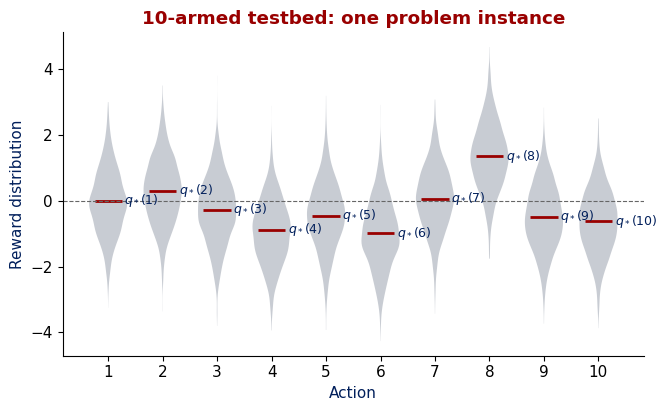

In [16]:
rng = np.random.default_rng(7)
q_star = rng.standard_normal(10)
samples = np.array([rng.standard_normal(2000) + q for q in q_star]).T

fig, ax = plt.subplots(figsize=(7.5, 4.2))
parts = ax.violinplot(samples, positions=range(1, 11), widths=0.7,
                       showmeans=False, showextrema=False, showmedians=False)
for pc in parts['bodies']:
    pc.set_facecolor("#9CA3AF"); pc.set_alpha(0.55); pc.set_edgecolor("none")
for i, q in enumerate(q_star, start=1):
    ax.hlines(q, i - 0.25, i + 0.25, colors=PENN_RED, linewidth=2)
    ax.text(i + 0.30, q, f"$q_*({i})$", color=PENN_BLUE, fontsize=9, va="center")
ax.axhline(0, color="#666", linestyle="--", linewidth=0.8)
ax.set_xticks(range(1, 11))
ax.set_xlabel("Action"); ax.set_ylabel("Reward distribution")
ax.set_title("10-armed testbed: one problem instance")
plt.savefig(FIG_DIR / "fig_violins.png"); plt.show()

## 2. The general experiment loop

Every learning curve in the deck is an average over many independent runs. Each run gets a fresh bandit problem so we measure the *algorithm*, not a lucky draw of $q_*$.

In [17]:
def run_agent(agent_fn, steps=1000, runs=500, k=10, seed=0, q_offset=0.0):
    """Run agent_fn across `runs` independent bandit problems; average results."""
    avg_reward = np.zeros(steps)
    pct_optimal = np.zeros(steps)
    master = np.random.default_rng(seed)
    for _ in range(runs):
        rng = np.random.default_rng(master.integers(1 << 31))
        bandit = Bandit(k=k, rng=rng, q_offset=q_offset)
        rewards, opt = agent_fn(bandit, steps)
        avg_reward += rewards
        pct_optimal += opt
    return avg_reward / runs, pct_optimal / runs

## 3. ε-greedy agent (Pack A, slide on action selection)

$$A_t = \begin{cases} \arg\max_a Q_t(a) & \text{w.p. } 1-\varepsilon \\ \text{random action} & \text{w.p. } \varepsilon \end{cases}$$

The update is the sample average, written incrementally:

$$Q_{n+1} = Q_n + \tfrac{1}{N(a)}\,\bigl(R_n - Q_n\bigr).$$

In [18]:
def epsilon_greedy_agent(epsilon, Q_init=0.0, alpha=None):
    """alpha=None  -> sample-average (1/N)
       alpha=float -> constant step-size (recency-weighted)"""
    def fn(bandit, steps):
        Q = np.full(bandit.k, Q_init, dtype=float)
        N = np.zeros(bandit.k, dtype=int)
        rewards = np.zeros(steps); opt = np.zeros(steps)
        rng = bandit.rng
        for t in range(steps):
            a = rng.integers(bandit.k) if rng.random() < epsilon else int(np.argmax(Q))
            r = bandit.step(a)
            N[a] += 1
            step = (1.0 / N[a]) if alpha is None else alpha
            Q[a] += step * (r - Q[a])
            rewards[t] = r
            opt[t] = float(a == bandit.optimal)
        return rewards, opt
    return fn

### Figure 2.2 — comparing $\varepsilon$

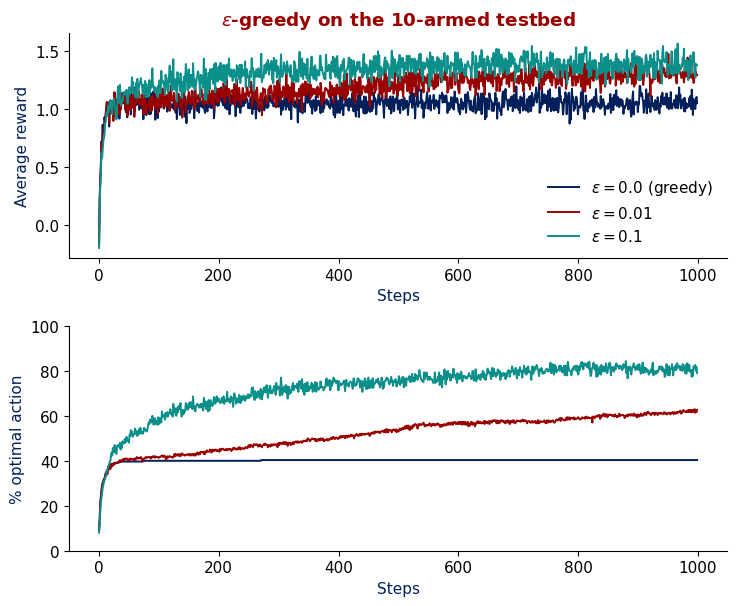

In [19]:
eps_values = [0.0, 0.01, 0.1]
colors = {0.0: PENN_BLUE, 0.01: PENN_RED, 0.1: TEAL}
results = {e: run_agent(epsilon_greedy_agent(e), steps=1000, runs=300, seed=11)
           for e in eps_values}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 6.2))
for e in eps_values:
    label = f"$\\varepsilon={e}$" + (" (greedy)" if e == 0 else "")
    ax1.plot(results[e][0], color=colors[e], label=label, linewidth=1.4)
    ax2.plot(100 * results[e][1], color=colors[e], linewidth=1.4)
ax1.set_ylabel("Average reward"); ax1.set_xlabel("Steps")
ax1.legend(frameon=False, loc="lower right")
ax1.set_title(r"$\varepsilon$-greedy on the 10-armed testbed")
ax2.set_ylabel("% optimal action"); ax2.set_xlabel("Steps"); ax2.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_epsilon_greedy.png"); plt.show()

**What to notice.** The pure-greedy agent ($\varepsilon=0$) gets stuck. $\varepsilon=0.1$ explores aggressively and learns fast but always wastes 10% of pulls. $\varepsilon=0.01$ catches up eventually — slower learning, higher asymptote.

## 4. Optimistic initial values (Pack B)

Initialize $Q_1(a) = 5$ for all $a$ — a value bigger than any realistic reward. Every disappointment ($r < Q$) drives $Q$ down, so the greedy agent is *forced* to try other arms.

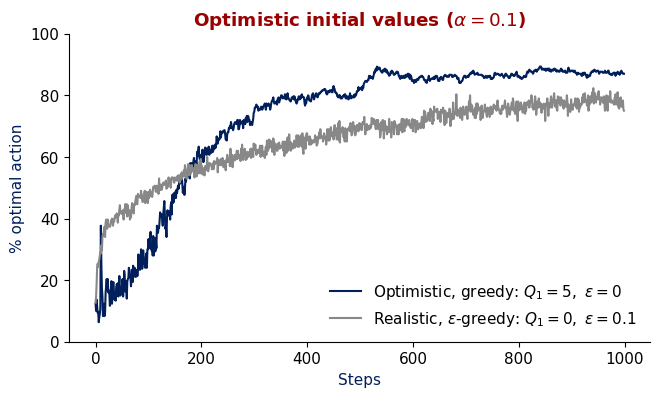

In [20]:
real = run_agent(epsilon_greedy_agent(0.1, Q_init=0.0, alpha=0.1),
                 steps=1000, runs=300, seed=22)
opt  = run_agent(epsilon_greedy_agent(0.0, Q_init=5.0, alpha=0.1),
                 steps=1000, runs=300, seed=22)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(100 * opt[1],  color=PENN_BLUE, linewidth=1.5,
        label=r"Optimistic, greedy: $Q_1=5,\ \varepsilon=0$")
ax.plot(100 * real[1], color="#888888", linewidth=1.5,
        label=r"Realistic, $\varepsilon$-greedy: $Q_1=0,\ \varepsilon=0.1$")
ax.set_xlabel("Steps"); ax.set_ylabel("% optimal action"); ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="lower right")
ax.set_title(r"Optimistic initial values ($\alpha=0.1$)")
plt.savefig(FIG_DIR / "fig_optimistic.png"); plt.show()

## 5. Upper-Confidence-Bound (UCB)

$$A_t = \arg\max_a \Bigl[\, Q_t(a) + c\,\sqrt{\tfrac{\log t}{N_t(a)}}\,\Bigr]$$

Bonus shrinks the more we pull arm $a$, and grows with $t$ for arms we *haven't* pulled.

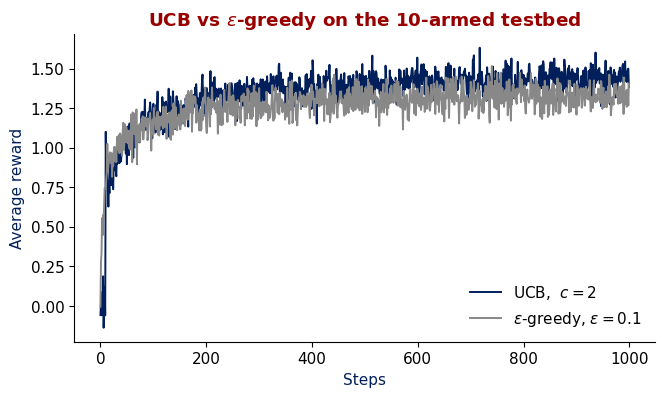

In [21]:
def ucb_agent(c):
    def fn(bandit, steps):
        Q = np.zeros(bandit.k); N = np.zeros(bandit.k, dtype=int)
        rewards = np.zeros(steps); opt = np.zeros(steps)
        for t in range(steps):
            untried = np.where(N == 0)[0]
            if len(untried) > 0:
                a = int(untried[0])
            else:
                bonus = c * np.sqrt(np.log(t + 1) / N)
                a = int(np.argmax(Q + bonus))
            r = bandit.step(a); N[a] += 1
            Q[a] += (r - Q[a]) / N[a]
            rewards[t] = r; opt[t] = float(a == bandit.optimal)
        return rewards, opt
    return fn

ucb = run_agent(ucb_agent(c=2.0), steps=1000, runs=300, seed=33)
eg  = run_agent(epsilon_greedy_agent(0.1), steps=1000, runs=300, seed=33)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(ucb[0], color=PENN_BLUE, linewidth=1.4, label="UCB,  $c=2$")
ax.plot(eg[0],  color="#888888", linewidth=1.4, label=r"$\varepsilon$-greedy, $\varepsilon=0.1$")
ax.set_xlabel("Steps"); ax.set_ylabel("Average reward")
ax.legend(frameon=False, loc="lower right")
ax.set_title(r"UCB vs $\varepsilon$-greedy on the 10-armed testbed")
plt.savefig(FIG_DIR / "fig_ucb.png"); plt.show()

## 6. Gradient bandit

Maintain preferences $H_t(a)$. Sample actions via softmax. Update toward better-than-baseline rewards.

$$\pi_t(a) = \frac{e^{H_t(a)}}{\sum_b e^{H_t(b)}}, \qquad H_{t+1}(a) = H_t(a) + \alpha\,(R_t - \bar R_t)\,(\mathbb{1}_{a=A_t} - \pi_t(a))$$

To stress-test the baseline, we shift all $q_*(a)$ up by 4.

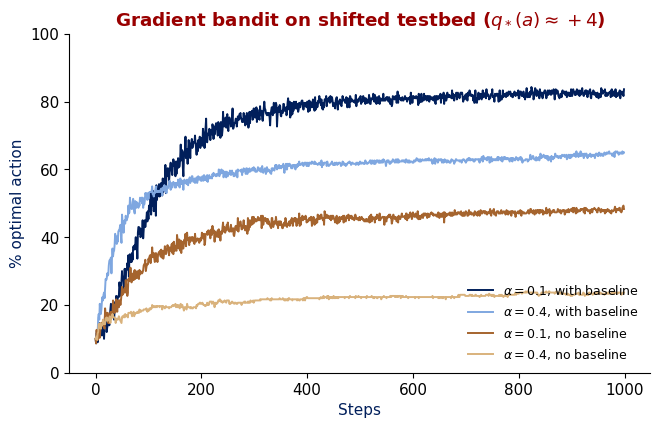

In [22]:
def gradient_bandit_agent(alpha, use_baseline=True):
    def fn(bandit, steps):
        H = np.zeros(bandit.k)
        rewards = np.zeros(steps); opt = np.zeros(steps)
        avg_r = 0.0
        for t in range(steps):
            expH = np.exp(H - H.max())
            pi = expH / expH.sum()
            a = int(bandit.rng.choice(bandit.k, p=pi))
            r = bandit.step(a)
            baseline = avg_r if use_baseline else 0.0
            one_hot = np.zeros(bandit.k); one_hot[a] = 1.0
            H += alpha * (r - baseline) * (one_hot - pi)
            avg_r += (r - avg_r) / (t + 1)
            rewards[t] = r; opt[t] = float(a == bandit.optimal)
        return rewards, opt
    return fn

configs = [
    (0.1, True,  PENN_BLUE,  r"$\alpha=0.1$, with baseline"),
    (0.4, True,  "#7FA7E0",  r"$\alpha=0.4$, with baseline"),
    (0.1, False, "#A5642E",  r"$\alpha=0.1$, no baseline"),
    (0.4, False, "#D9B27C",  r"$\alpha=0.4$, no baseline"),
]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for alpha, baseline, color, label in configs:
    _, pct_opt = run_agent(gradient_bandit_agent(alpha, baseline),
                            steps=1000, runs=300, seed=44, q_offset=4.0)
    ax.plot(100 * pct_opt, color=color, linewidth=1.4, label=label)
ax.set_xlabel("Steps"); ax.set_ylabel("% optimal action"); ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title(r"Gradient bandit on shifted testbed ($q_*(a) \approx +4$)")
plt.savefig(FIG_DIR / "fig_gradient.png"); plt.show()

## 7. Recency weights (constant $\alpha$ vs. sample average)

Before the nonstationary experiment, it helps to *see* why a constant step-size
$\alpha$ is called an **exponential recency-weighted average**. Unrolling the update
gives each past reward $R_i$ a weight

$$w_i = \alpha\,(1-\alpha)^{\,n-i},$$

which is largest for the most recent reward and decays geometrically into the past.
A sample average ($1/N$), by contrast, weights every reward equally.

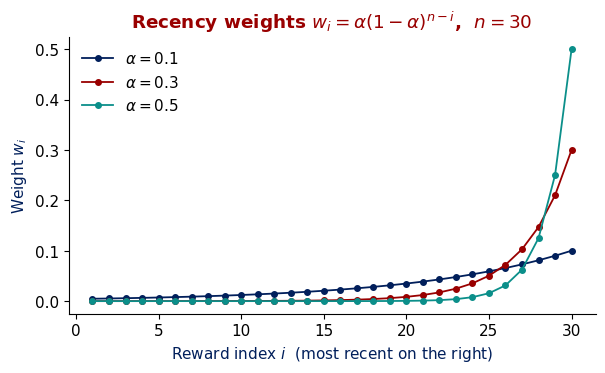

In [23]:
n = 30
i = np.arange(1, n + 1)
fig, ax = plt.subplots(figsize=(6.8, 3.6))
for alpha, c in [(0.1, PENN_BLUE), (0.3, PENN_RED), (0.5, TEAL)]:
    w = alpha * (1 - alpha) ** (n - i)
    ax.plot(i, w, marker="o", markersize=4, linewidth=1.3, color=c, label=rf"$\alpha={alpha}$")
ax.set_xlabel("Reward index $i$  (most recent on the right)")
ax.set_ylabel(r"Weight $w_i$")
ax.set_title(r"Recency weights $w_i=\alpha(1-\alpha)^{n-i}$,  $n=30$")
ax.legend(frameon=False)
plt.savefig(FIG_DIR / "fig_recency_weights.png"); plt.show()

## 8. Nonstationary problem — why constant $\alpha$ wins

If $q_*(a)$ drifts as a random walk, recent rewards are more informative than old ones. The sample-average estimator is too sluggish to keep up.

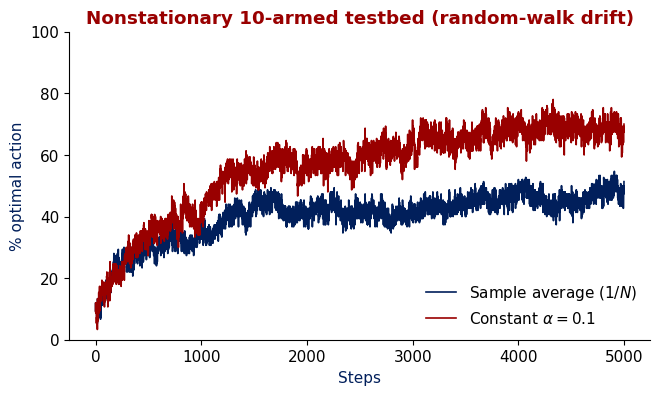

In [24]:
class NonstationaryBandit:
    def __init__(self, k=10, rng=None, drift=0.01):
        self.k = k; self.rng = rng or np.random.default_rng()
        self.q_star = np.zeros(k); self.drift = drift
    def step(self, a):
        r = self.rng.standard_normal() + self.q_star[a]
        self.q_star += self.drift * self.rng.standard_normal(self.k)
        self.optimal = int(np.argmax(self.q_star))
        return r

def run_nonstationary(agent_fn, runs=150, steps=5000, seed=0):
    avg_r = np.zeros(steps); pct_opt = np.zeros(steps)
    master = np.random.default_rng(seed)
    for _ in range(runs):
        b = NonstationaryBandit(rng=np.random.default_rng(master.integers(1 << 31)))
        b.optimal = 0
        rs, op = agent_fn(b, steps); avg_r += rs; pct_opt += op
    return avg_r / runs, pct_opt / runs

sa = run_nonstationary(epsilon_greedy_agent(0.1, alpha=None), seed=55)
ca = run_nonstationary(epsilon_greedy_agent(0.1, alpha=0.1),  seed=55)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(100 * sa[1], color=PENN_BLUE, linewidth=1.2, label="Sample average ($1/N$)")
ax.plot(100 * ca[1], color=PENN_RED,  linewidth=1.2, label=r"Constant $\alpha=0.1$")
ax.set_xlabel("Steps"); ax.set_ylabel("% optimal action"); ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Nonstationary 10-armed testbed (random-walk drift)")
plt.savefig(FIG_DIR / "fig_nonstationary.png"); plt.show()

## 9. Parameter study — comparing all methods

Finally, the summary comparison: sweep each method's main hyperparameter and plot the
average reward over the first 1000 steps. **The point is the shape and the peak of each
curve, not a single winner** — the best method depends on the problem.

> This cell runs all four algorithms across many parameter values, so it is the slowest
> in the notebook. Reduce `runs` if you just want to see the shape quickly.

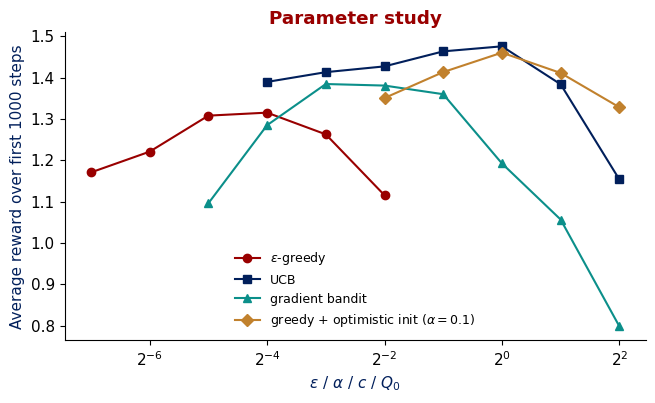

In [37]:
def parameter_study(runs=200, steps=1000, file_suffix=''):
    eg_eps = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4]
    eg = [run_agent(epsilon_greedy_agent(e), runs=runs, steps=steps, seed=66)[0].mean()
          for e in eg_eps]
    ucb_c = [1/16, 1/8, 1/4, 1/2, 1, 2, 4]
    ub = [run_agent(ucb_agent(c), runs=runs, steps=steps, seed=66)[0].mean()
          for c in ucb_c]
    grad_a = [1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
    gr = [run_agent(gradient_bandit_agent(a, True), runs=runs, steps=steps, seed=66)[0].mean()
          for a in grad_a]
    opt_q = [1/4, 1/2, 1, 2, 4]
    op = [run_agent(epsilon_greedy_agent(0.0, Q_init=q1, alpha=0.1), runs=runs, steps=steps, seed=66)[0].mean()
          for q1 in opt_q]

    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    ax.plot(eg_eps, eg, marker="o", color=PENN_RED,  label=r"$\varepsilon$-greedy")
    ax.plot(ucb_c,  ub, marker="s", color=PENN_BLUE, label=r"UCB")
    ax.plot(grad_a, gr, marker="^", color=TEAL,      label=r"gradient bandit")
    ax.plot(opt_q,  op, marker="D", color=GOLD,      label=r"greedy + optimistic init ($\alpha=0.1$)")
    ax.set_xscale("log", base=2)
    ax.set_xlabel(r"$\varepsilon\ /\ \alpha\ /\ c\ /\ Q_0$")
    ax.set_ylabel("Average reward over first 1000 steps")
    ax.legend(frameon=False, loc="lower center", fontsize=9)
    ax.set_title("Parameter study")
    plt.savefig(FIG_DIR / f"fig_parameter_study{file_suffix}.png"); plt.show()

# Slowest cell in the notebook — lower `runs` for a quick look, raise for smoothness.
parameter_study(runs=200)

## 10. Discussion

- **ε-greedy:** is there a principled way to *decrease* $\varepsilon$ over time? What would you want to depend on?
- **UCB:** what happens when $c$ is very large? Very small? Try changing it in the code.
- **Gradient bandit without baseline:** explain *why* it collapses on the shifted testbed. Hint: gradient direction is fine, but step *magnitude* explodes.
- **Nonstationary:** what would $\alpha$ need to do to track *and* converge? (Robbins–Monro conditions.)


# HW Problem 3
## a): $\varepsilon$-greedy, UCB, and gradient results compared



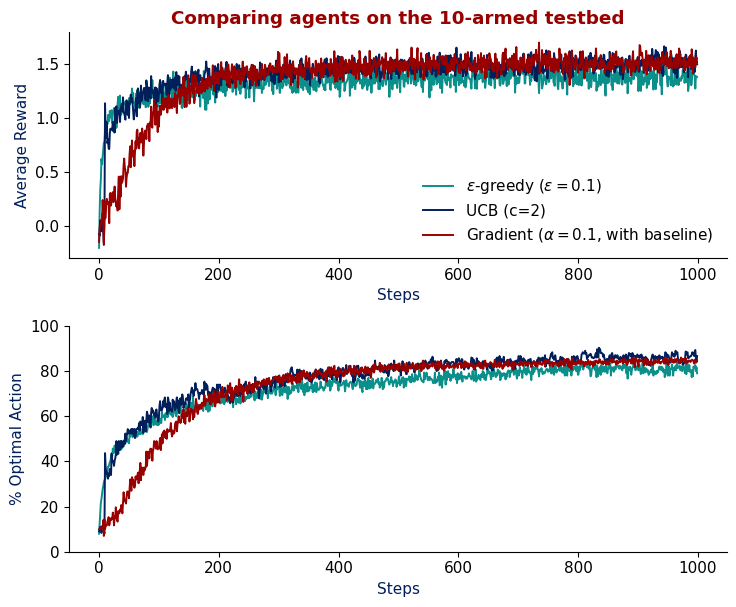

In [34]:
def compare_three(eps, c, alpha, out_file):
    labels = [f"$\\varepsilon$-greedy ($\\varepsilon={eps}$)", f"UCB (c={c})", f"Gradient ($\\alpha={alpha}$, with baseline)"]
    colors = [TEAL, PENN_BLUE, PENN_RED]
    agents = [epsilon_greedy_agent(eps), ucb_agent(c), gradient_bandit_agent(alpha)]
    results = [run_agent(a, steps=1000, runs=300, seed=11) for a in agents]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 6.2))
    for label, result, color in zip(labels, results, colors):
        ax1.plot(result[0], color=color, label=label, linewidth=1.4)
        ax2.plot(100 * result[1], color=color, linewidth = 1.4)
    ax1.set_ylabel("Average Reward")
    ax1.legend(frameon=False, loc="lower right")
    ax1.set_xlabel("Steps")
    ax1.set_title("Comparing agents on the 10-armed testbed")
    ax2.set_ylabel("% Optimal Action")
    ax2.set_xlabel("Steps")
    ax2.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(FIG_DIR / out_file)
    plt.show()

compare_three(0.1, 2, 0.1, "ps3_a.png")

The gradient and UCB approaches both appear to reach a similarly high average reward, though the gradient bandit takes longer to learn than the other methods. UCB also appears to have the highest optimal action percentage, indicating that for this testbed & chosen metaparameters, it seems to be the ideal choice.

## b): Tweaking Metaparameters

![Parameter Study](figures/fig_parameter_study.png)

Looking at the original parameter study curves, it seems each has a local maxima. In an attempt to improve the average reward, I want to try and pick untested values near those maxima to see if there are better options hiding "between" the sampled points. Since the parameter study is looking at average reward across all 1000 steps and the existing agents are most likely converging to near-optimal policies, I would expect to see an improvement in convergence rate for all three approaches (if the parameters I'm selecting are actually improvements- otherwise I would expect a slower convergence rate.)

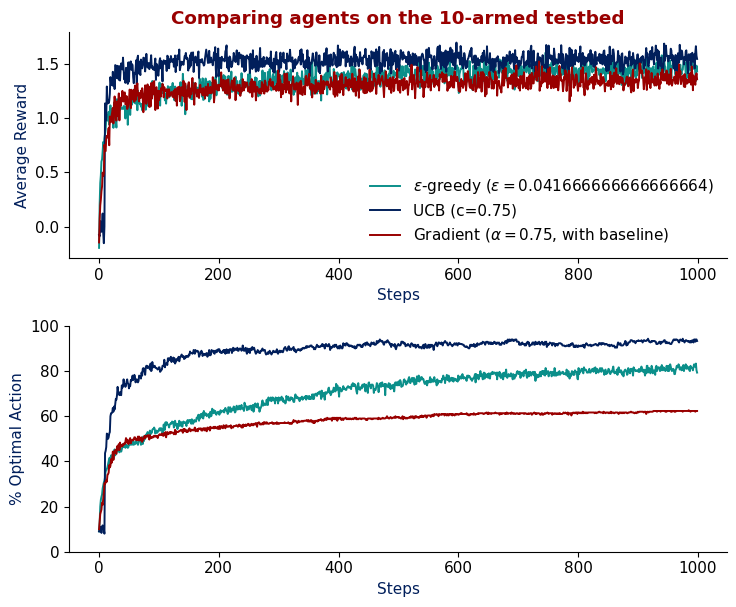

In [35]:
compare_three(1/24, 0.75, 0.75, "ps3_b.png")

My hypothesis that the agents would coverge faster appears to have been correct - this is evident by the much steeper curve in the first few steps that levels off quickly.

What I did not anticipate (but in hindisght should have) the % optimal action decreased dramatically for both the $\varepsilon$-greedy and gradient agents. In fact, the gradient agent now converges to a lower average return than the $\varepsilon$-greedy agent. This is representative of the inherrent tradeoff between quick convergence and finding an optimal policy - when these agents converge, they are ending exploration that might lead to a better result. This does lead to a higher average return over the first 1000 steps, at the expense of the actual reward the agent learns to receive. This makes me suspect that if we ran our parameter study for a larger number of steps, we would "penalize" the agents less for the time they take to learn since we give them more time to reap the advantage of having found a higher return arm.

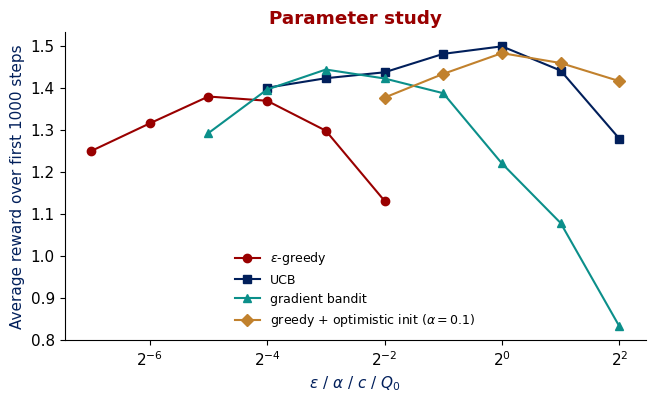

In [38]:
parameter_study(runs=200, steps=2000, file_suffix="_2k")

This does seem to shift the curves, but not as significantly as expected. I think that I would need to run the study even longer for the average reward to not be dragged down by the early steps where the agents are exploring.

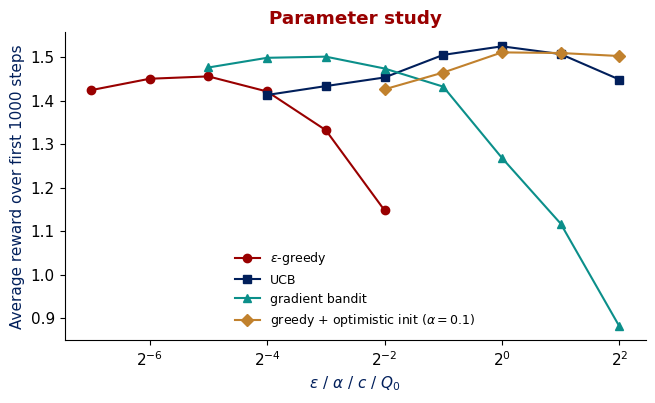

In [39]:
parameter_study(runs=200, steps=10000, file_suffix="_10k")

As I suspected, the local maxima of the curves has shifted. I would expect values near these maxima to converge slower than my last test, but have higher % optimal action.

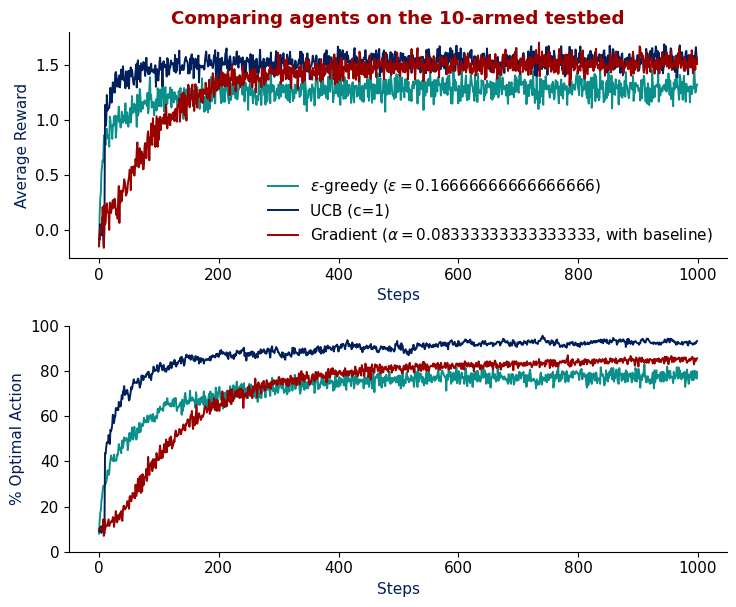

In [43]:
compare_three(1/6, 1, 1/12, "ps3_b2")

As expected, when compared to the previous test, the convergence rate for the gradient agent has decreased but the % optimal action has increased.

## c): Nonstationary

![Nonstationary testbed](figures/fig_nonstationary.png)

As discussed in problem 1a, the sample average approach's step size decreases over time, making it less capable of adjusting to the change in observed rewards. This explains the fact that as time continues, the constant $\alpha$ approach outperforms the sample average.

If I were choosing an agent to deploy in an environment I knew ahead of time to be perpetually non-stationary, I would likely use a gradient agent, using the average observed reward as a baseline. My rationale is that with a well chosen $\alpha$, we can expect the agent to continue to adjust it's preferences as the rewards drift. My concern with UCB is that while it's bonus factor does encourage continued exploration over time, the asymptotic nature of $log(t)$ means that as $t$ approaches infinity, $N_{t}(s)$ will dominate the bonus factor and reduce it too far to sufficiently introduce exploration (similar to the issues with sample averaging), whereas the constant $\alpha$ used in the gradient approach will remain constant.